# Titanic Dataset Visualization Dashboard

## Objective

The objective of this project is to create a mini visualization dashboard using the Titanic dataset.

This project includes:

- Loading the dataset
- Cleaning missing values
- Creating new features
- Building multiple visualizations
- Understanding survival patterns
- Drawing conclusions from the visualizations

The following visualizations will be created:

1. Age Distribution
2. Survival Rate by Gender
3. Fare Distribution by Passenger Class
4. Age vs Fare Scatter Plot
5. Correlation Heatmap

In [1]:
# Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Apply seaborn style
sns.set()

# Display plots in notebook
%matplotlib inline

## Loading the Dataset

The Titanic dataset is loaded into a Pandas DataFrame to begin the analysis.

In [2]:
# Load Dataset

df = pd.read_csv("Titanic-Dataset.csv")

# Display first five rows

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Understanding the Dataset

Before starting the analysis, it is important to understand the dataset structure, data types, and missing values.

In [3]:
# Dataset Shape

print("Shape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")

df.info()

Shape of Dataset:
(891, 12)

Column Names:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [4]:
# Check Missing Values

df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Data Cleaning

The dataset contains missing values in some columns.

Cleaning steps:

- Fill missing Age values using the median.
- Fill missing Embarked values using the mode.
- Remove the Cabin column because it contains many missing values.

In [5]:
# Fill Missing Age Values

df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill Missing Embarked Values

df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Remove Cabin Column

df.drop("Cabin", axis=1, inplace=True)

# Verify Missing Values

df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

## Feature Engineering

A new feature called **Family Size** is created by adding the **SibSp** and **Parch** columns.

Passengers are also divided into age groups to simplify age-based analysis.

In [6]:
# Create Family Size

df["FamilySize"] = df["SibSp"] + df["Parch"]

# Create Age Groups

bins = [0,12,18,30,50,80]

labels = [
    "Child",
    "Teen",
    "Young Adult",
    "Adult",
    "Senior"
]

df["AgeGroup"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels
)

# Display Dataset

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,AgeGroup
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,1,Young Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1,Adult
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0,Young Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1,Adult
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0,Adult


## Visualization 1

### Age Distribution of Passengers

A histogram is used to understand the distribution of passenger ages. This helps identify which age groups were most common on the Titanic.

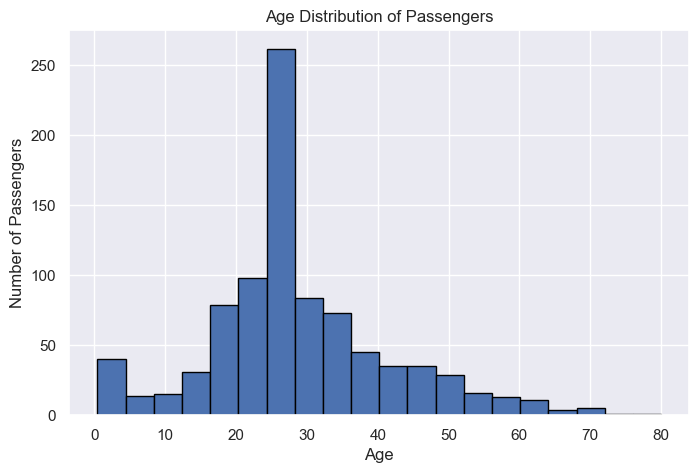

In [7]:
# Histogram of Passenger Ages

plt.figure(figsize=(8,5))

plt.hist(
    df["Age"],
    bins=20,
    edgecolor="black"
)

plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

## Observation

Most passengers were young adults between 20 and 40 years of age. The number of passengers gradually decreased as age increased.

## Visualization 2

### Survival Rate by Gender

A bar chart is used to compare the survival rates of male and female passengers.

Sex
female    74.203822
male      18.890815
Name: Survived, dtype: float64


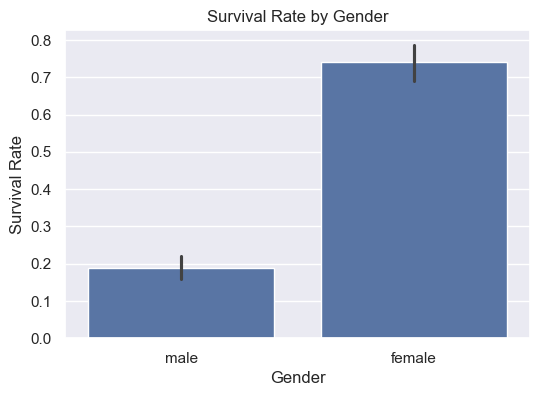

In [8]:
# Survival Rate by Gender

gender_survival = df.groupby("Sex")["Survived"].mean() * 100

print(gender_survival)

plt.figure(figsize=(6,4))

sns.barplot(
    x="Sex",
    y="Survived",
    data=df
)

plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")

plt.show()

## Observation

Female passengers had a much higher survival rate than male passengers. This indicates that gender was one of the major factors influencing survival during the disaster.

## Visualization 3

### Fare Distribution by Passenger Class

A box plot is used to compare ticket fares across different passenger classes and identify the spread of fares.

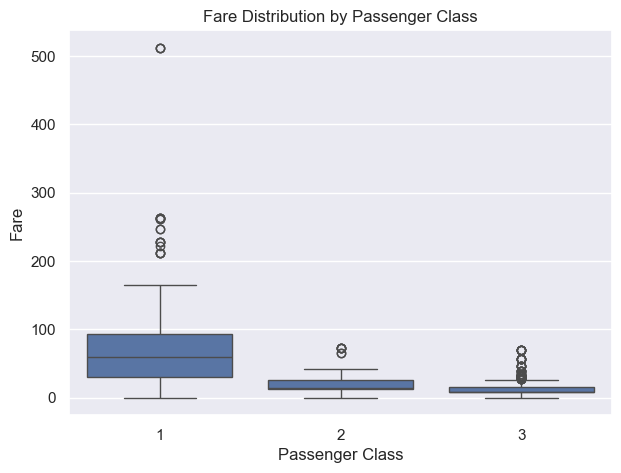

In [9]:
# Fare Distribution by Passenger Class

plt.figure(figsize=(7,5))

sns.boxplot(
    x="Pclass",
    y="Fare",
    data=df
)

plt.title("Fare Distribution by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")

plt.show()

## Observation

First-class passengers generally paid higher fares than passengers in second and third class. The box plot also shows greater variation in fares among first-class passengers.

## Dashboard Summary

The first three visualizations provide insights into passenger age distribution, survival by gender, and fare differences across passenger classes. These charts help understand the characteristics of passengers and the factors associated with survival.

## Visualization 4

### Relationship Between Age and Fare

A scatter plot is used to examine whether there is any relationship between a passenger's age and the fare they paid.

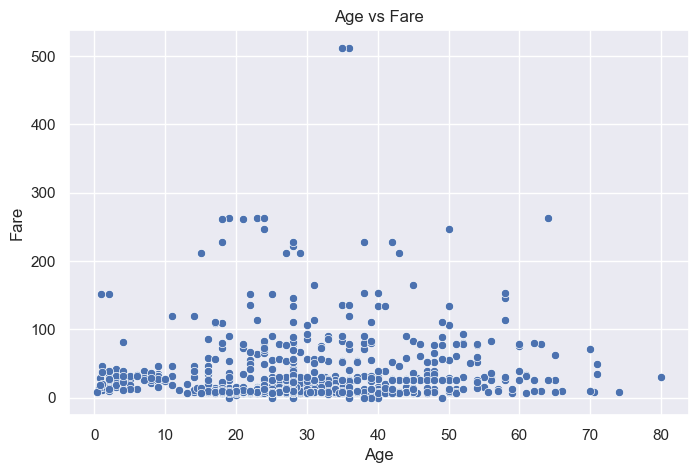

In [10]:
# Scatter Plot: Age vs Fare

plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Age",
    y="Fare",
    data=df
)

plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.show()

## Observation

The scatter plot does not show a strong relationship between age and fare. Most passengers paid lower fares, while a few passengers paid significantly higher fares regardless of their age.

## Visualization 5

### Correlation Heatmap

A heatmap is created to understand the relationships between numerical features in the dataset.

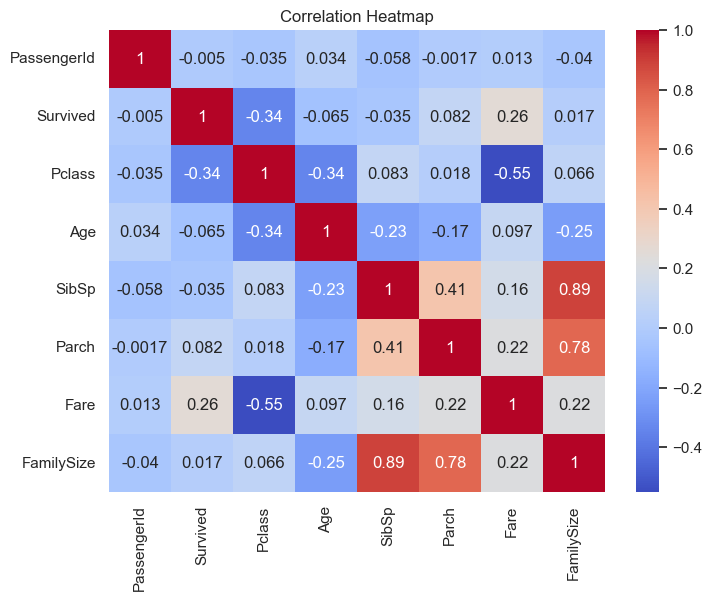

In [11]:
# Correlation Heatmap

plt.figure(figsize=(8,6))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

## Observation

The heatmap shows that passenger class, fare, and survival have noticeable relationships. Features such as Passenger Class and Fare are negatively correlated because first-class passengers generally paid higher fares.

## Optional Visualization

### Survival Rate by Gender and Passenger Class

This visualization compares survival rates for different passenger classes separately for males and females.

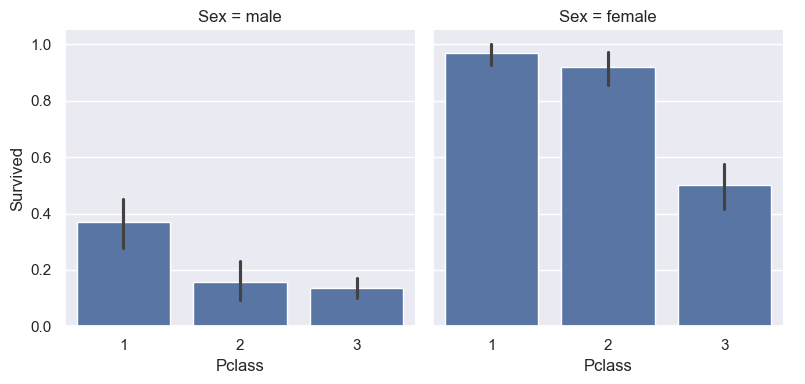

In [12]:
# Optional Visualization

sns.catplot(
    col="Sex",
    x="Pclass",
    y="Survived",
    kind="bar",
    data=df,
    height=4,
    aspect=1
)

plt.show()

## Observation

Female passengers had higher survival rates across all passenger classes. First-class passengers generally had better survival rates than second- and third-class passengers for both males and females.

## Final Conclusion

The Titanic visualization dashboard provided valuable insights into passenger characteristics and survival patterns.

### Key Findings

1. Most passengers were young adults between 20 and 40 years of age.
2. Female passengers had a much higher survival rate than male passengers.
3. First-class passengers generally paid higher fares and had better survival chances.
4. There was no strong relationship between passenger age and ticket fare.
5. The correlation heatmap highlighted relationships between passenger class, fare, and survival.
6. Female passengers consistently showed higher survival rates across all passenger classes.

Overall, this project demonstrates how **Pandas, Matplotlib, and Seaborn** can be used to clean data, create effective visualizations, and communicate meaningful insights through a simple dashboard.